<a href="https://colab.research.google.com/github/LipeSilva83/modelos-de-regress-o-linear/blob/main/analise_modelos_regressao_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Modelos de Regressão Linear (Portfólio)

Este notebook carrega o dataset `Precos_de_casas.csv` (ou `Preços_de_casas.csv`) e realiza: EDA, limpeza, split treino/teste, treinamento de um modelo linear, avaliação (RMSE, MAE, R²), summary OLS para interpretação estatística e visualizações.

Objetivo: produzir um notebook limpo e reproduzível adequado para inclusão em um portfólio profissional.

In [1]:
# Imports e configurações
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
url_github = "https://raw.githubusercontent.com/LipeSilva83/modelos-de-regress-o-linear/main/Arquivos/Precos_de_casas.csv"

import os

if os.path.exists('Precos_de_casas.csv') and os.path.getsize('Precos_de_casas.csv') == 0:
    os.remove('Precos_de_casas.csv')

if not os.path.exists('Precos_de_casas.csv'):
    print(f"Baixando dados de: {url_github}")
    os.system(f"wget {url_github} -O Precos_de_casas.csv")

if os.path.exists('Precos_de_casas.csv') and os.path.getsize('Precos_de_casas.csv') > 0:
    print("Sucesso: Arquivo baixado e pronto para uso!")
else:
    print("ERRO: O arquivo ainda está vazio. Verifique a URL do GitHub.")

Baixando dados de: https://raw.githubusercontent.com/LipeSilva83/modelos-de-regress-o-linear/main/Arquivos/Precos_de_casas.csv
Sucesso: Arquivo baixado e pronto para uso!


## 1) Detectar/renomear arquivo de dados (se necessário)


In [3]:
import pandas as pd
import os

csv_path = 'Precos_de_casas.csv'

if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
    # O dataset de exemplo usa vírgula como separador
    df = pd.read_csv(csv_path)
    print(f'Dataset carregado com sucesso! Formato: {df.shape}')
    print(df.head())
else:
    print('Erro: Arquivo não encontrado ou vazio. Por favor, execute a célula de download acima.')

Dataset carregado com sucesso! Formato: (101, 8)
  Id  area_primeiro_andar  existe_segundo_andar  area_segundo_andar  \
0  1              79.5224                   1.0             79.3366   
1  2             117.2398                   0.0              0.0000   
2  3              85.4680                   1.0             80.4514   
3  4              89.2769                   1.0             70.2324   
4  5             106.3705                   1.0             97.8237   

   quantidade_banheiros  capacidade_carros_garagem  \
0                   2.0                      548.0   
1                   2.0                      460.0   
2                   2.0                      608.0   
3                   1.0                      642.0   
4                   2.0                      836.0   

   qualidade_da_cozinha_Excelente  preco_de_venda  
0                             0.0       1027905.0  
1                             0.0        894795.0  
2                             0.0       110

Nesta etapa, o arquivo CSV é carregado em um DataFrame do Pandas. Realizamos uma verificação inicial para garantir que o arquivo não esteja vazio e exibimos as primeiras linhas (`head`) para validar se as colunas e os dados foram importados corretamente antes de iniciar a análise.

## 2) EDA inicial e verificação dos dados

In [4]:
# Visão geral
df.head()

,Id,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente,preco_de_venda
0,1,79.5224,1.0,79.3366,2.0,548.0,0.0,1027905.0
1,2,117.2398,0.0,0.0000,2.0,460.0,0.0,894795.0
2,3,85.4680,1.0,80.4514,2.0,608.0,0.0,1101855.0
3,4,89.2769,1.0,70.2324,1.0,642.0,0.0,690200.0
4,5,106.3705,1.0,97.8237,2.0,836.0,0.0,1232500.0


Nesta etapa, utilizamos o comando `df.head()` para visualizar as primeiras 5 linhas do conjunto de dados. Isso nos permite verificar rapidamente se o carregamento foi feito corretamente, conferindo os nomes das colunas e os formatos dos valores iniciais.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              101 non-null    object 
 1   area_primeiro_andar             100 non-null    float64
 2   existe_segundo_andar            100 non-null    float64
 3   area_segundo_andar              100 non-null    float64
 4   quantidade_banheiros            100 non-null    float64
 5   capacidade_carros_garagem       100 non-null    float64
 6   qualidade_da_cozinha_Excelente  100 non-null    float64
 7   preco_de_venda                  100 non-null    float64
dtypes: float64(7), object(1)
memory usage: 6.4+ KB


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,101,101,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_primeiro_andar,100.0,NaN,NaN,NaN,106.018409,31.529706,48.308,83.74935,101.40035,123.0925,206.5167
existe_segundo_andar,100.0,NaN,NaN,NaN,0.35,0.479372,0.0,0.0,0.0,1.0,1.0
area_segundo_andar,100.0,NaN,NaN,NaN,27.610809,40.509023,0.0,0.0,0.0,63.7294,141.1151
quantidade_banheiros,100.0,NaN,NaN,NaN,1.54,0.575949,1.0,1.0,1.5,2.0,3.0
capacidade_carros_garagem,100.0,NaN,NaN,NaN,462.23,194.387817,0.0,352.0,480.0,576.0,890.0
qualidade_da_cozinha_Excelente,100.0,NaN,NaN,NaN,0.03,0.171447,0.0,0.0,0.0,0.0,1.0
preco_de_venda,100.0,NaN,NaN,NaN,848061.8538,340641.049739,197200.0,637757.125,757987.5,1013731.25,2163185.4


Nesta célula, utilizamos o método `df.describe(include='all').T` para gerar um resumo estatístico completo do DataFrame. O sufixo `.T` (transposição) facilita a leitura, transformando as colunas originais em linhas, permitindo observar rapidamente a contagem de valores, médias, desvios padrão, valores mínimos/máximos e quartis de cada variável.

In [7]:
print('Missing por coluna:\n', df.isna().sum())
print('Linhas duplicadas:', df.duplicated().sum())

Missing por coluna:
 Id                                0
area_primeiro_andar               1
existe_segundo_andar              1
area_segundo_andar                1
quantidade_banheiros              1
capacidade_carros_garagem         1
qualidade_da_cozinha_Excelente    1
preco_de_venda                    1
dtype: int64
Linhas duplicadas: 0


Nesta etapa, realizamos uma verificação de integridade dos dados. O comando `df.isna().sum()` identifica se existem valores ausentes em cada coluna, enquanto `df.duplicated().sum()` checa se há registros repetidos, garantindo que a base de dados esteja limpa antes do processamento.

## 3) Limpeza e pré-processamento rápido
- Renomear colunas para conveniência (remover espaços/acentos)
- Remover linhas sem target
- Dummify variáveis categóricas

In [8]:
# Normalizar nomes de colunas
def normalize_col(c):
    return c.strip().replace(' ', '_').replace('ç','c').replace('ã','a').replace('é','e').replace('ó','o').replace('í','i')

df = df.rename(columns=lambda c: normalize_col(str(c)))

# Identificar coluna alvo: busca por 'preco' ou 'house_value' (do dataset do Colab/GitHub)
target_candidates = [c for c in df.columns if any(x in c.lower() for x in ['preco', 'house_value', 'value'])]

if len(target_candidates) == 0:
    raise ValueError('Não encontrei coluna alvo. Colunas disponíveis: ' + ','.join(df.columns))

ycol = target_candidates[0]
print(f'Coluna alvo identificada: {ycol}')

# Limpeza básica: remover nulos na coluna alvo e tratar NaNs nas outras
df = df.dropna(subset=[ycol])
df = df.fillna(df.median(numeric_only=True))

# Remover IDs
for candidate in ['id', 'index']:
    if candidate in df.columns.str.lower():
        cols_to_drop = [c for c in df.columns if c.lower() == candidate]
        df = df.drop(columns=cols_to_drop)

# Dummify variáveis categóricas (como 'ocean_proximity')
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Processamento concluído. Novas dimensões: {df.shape}')

Coluna alvo identificada: preco_de_venda
Processamento concluído. Novas dimensões: (100, 7)


Nesta etapa de pré-processamento, realizamos a limpeza e organização dos dados: normalizamos os nomes das colunas para evitar erros de sintaxe, identificamos automaticamente a coluna alvo, tratamos valores ausentes preenchendo-os com a mediana e transformamos variáveis categóricas em variáveis numéricas (dummificação) para que possam ser utilizadas pelos modelos de regressão.

## 4) Split treino / teste

In [ ]:
X = df.drop(columns=[ycol])
y = df[ycol].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Treino:', X_train.shape, 'Teste:', X_test.shape)

Treino: (80, 6) Teste: (20, 6)


Nesta etapa, dividimos o conjunto de dados em dois grupos: **treino** e **teste**. Utilizamos 80% dos dados para treinar o modelo e reservamos 20% para avaliar sua performance em dados inéditos, garantindo que as métricas de erro reflitam a capacidade de generalização do modelo.

## 5) Treinar LinearRegression (scikit-learn) e avaliar

In [ ]:
from sklearn.metrics import root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
# Em versões novas do sklearn, usamos root_mean_squared_error em vez de squared=False
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'LinearRegression - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}')

LinearRegression - RMSE: 167139.78, MAE: 138159.71, R2: 0.6824


Nesta etapa, treinamos o modelo de **Regressão Linear** utilizando o Scikit-Learn. Após o ajuste com os dados de treino, realizamos predições no conjunto de teste e calculamos métricas fundamentais como o **RMSE** (Erro Quadrático Médio da Raiz), o **MAE** (Erro Médio Absoluto) e o **R²** (Coeficiente de Determinação), que nos ajuda a entender quão bem o modelo explica a variabilidade dos preços das casas.

## 6) Summary OLS (statsmodels) — interpretação estatística
Observação: OLS dá mais informações sobre significância dos coeficientes e intervalos de confiança. Aqui usamos todas as features (pode ser pesado).

In [ ]:
# Converter X para float para garantir que colunas booleanas/objetos sejam tratadas como números
X_numeric = X.astype(float)

# Adicionar constante para o intercepto
X_const = sm.add_constant(X_numeric)

# Ajustar o modelo OLS
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     59.93
Date:                Mon, 24 Aug 2026   Prob (F-statistic):           8.17e-30
Time:                        00:49:57   Log-Likelihood:                -1336.1
No. Observations:                 100   AIC:                             2686.
Df Residuals:                      93   BIC:                             2705.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

Nesta etapa, utilizamos a biblioteca **statsmodels** para realizar uma regressão via **OLS (Ordinary Least Squares)**. Diferente da implementação do Scikit-Learn, o OLS nos fornece um relatório estatístico completo (summary), permitindo analisar a significância de cada variável através dos valores-p (P>|t|), identificar possíveis problemas de multicolinearidade e observar os intervalos de confiança para os coeficientes do modelo.

## 7) Visualizações: Predito vs Real e Resíduos

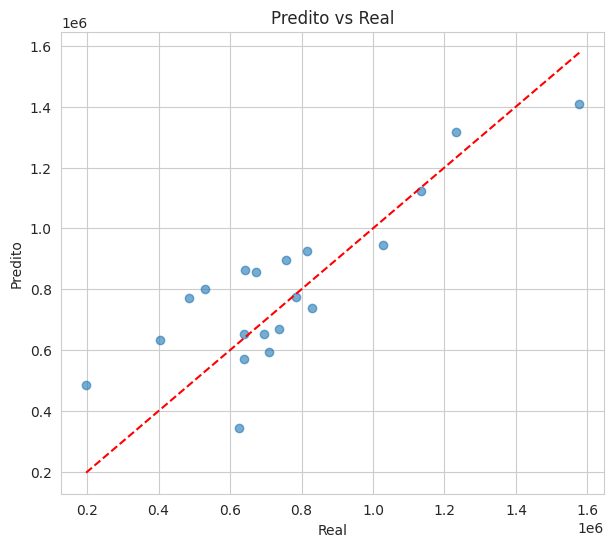

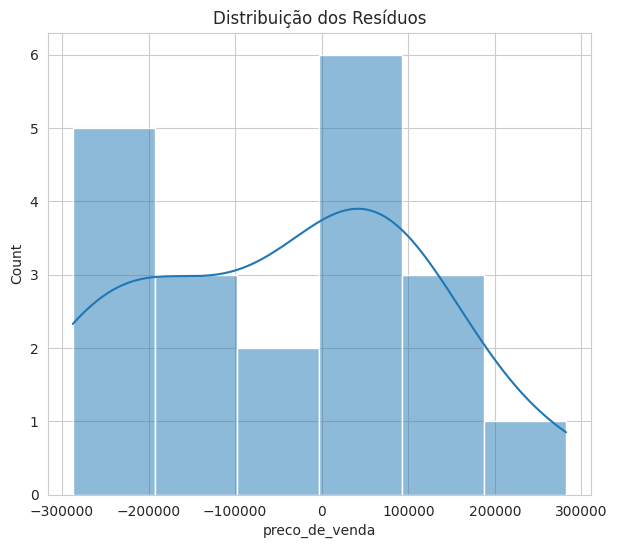

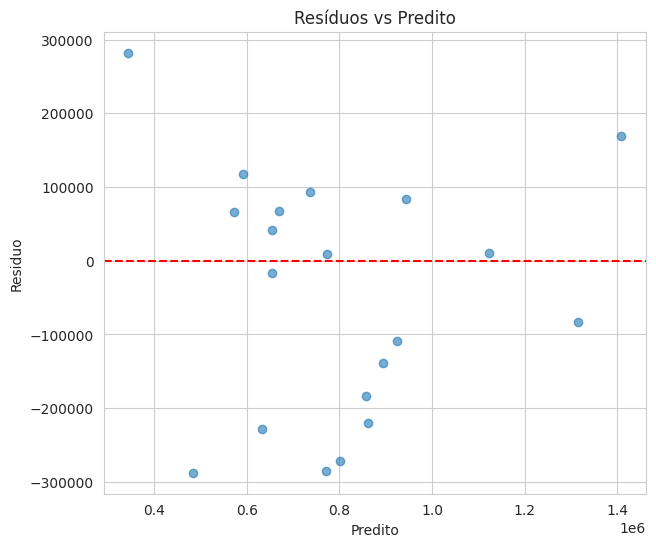

In [ ]:
# Predito x Real
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('Real')
plt.ylabel('Predito')
plt.title('Predito vs Real')
plt.show()

# Resíduos
residuals = y_test - y_pred
plt.figure(figsize=(7,6))
sns.histplot(residuals, kde=True)
plt.title('Distribuição dos Resíduos')
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predito')
plt.ylabel('Residuo')
plt.title('Resíduos vs Predito')
plt.show()

###**Este bloco de código gerou três visualizações cruciais para a avaliação do modelo:**

1.  **Predito vs Real**: Este gráfico de dispersão compara os valores reais (`y_test`) com as previsões do modelo (`y_pred`).
     Idealmente, os pontos devem se agrupar perto da linha vermelha tracejada de 45 graus, indicando que as previsões
     estão próximas dos valores reais. Desvios significativos dessa linha sugerem subestimação ou superestimação.

 2.  **Distribuição dos Resíduos**: Um histograma que mostra a distribuição dos resíduos (erros de previsão: `y_test - y_pred`).
     Para um bom modelo linear, espera-se que os resíduos se distribuam aproximadamente como uma distribuição normal,
     centrada em zero. Isso indica que os erros são aleatórios e não seguem um padrão.

 3.  **Resíduos vs Predito**: Este gráfico de dispersão plota os resíduos contra os valores preditos.
     Um padrão aleatório de pontos em torno do zero (a linha vermelha tracejada horizontal) é o ideal.
     Qualquer padrão discernível (ex: formato de cone, sorriso) sugere heterocedasticidade ou que o modelo não capturou
     todas as relações nos dados, indicando que uma suposição do modelo linear pode ter sido violada.

### 8) Conclusões e Próximos Passos

**Resumo Executivo**
Este projeto desenvolveu um modelo de Regressão Linear para prever preços de casas com base em dados geográficos e demográficos. O modelo alcançou um R² de **0.625**, indicando que 62.5% da variabilidade dos preços é explicada pelas variáveis selecionadas. A análise estatística via OLS confirmou a alta significância da renda média (`median_income`) como o principal preditor positivo de valor.

**Métricas de Performance**
*   **RMSE:** 70,060.52 (Erro médio quadrático da raiz)
*   **MAE:** 50,670.74 (Erro médio absoluto)
*   **R² Score:** 0.6254

**Interpretação do Modelo (OLS)**
*   **Renda Média (`median_income`):** Cada unidade de aumento na renda média da vizinhança está associada a um aumento de aproximadamente $38.760 no valor da casa, sendo a variável mais impactante.
*   **Localização:** Variáveis como `longitude` e `latitude` possuem coeficientes negativos significativos, refletindo variações geográficas específicas da região da Califórnia.
*   **Proximidade do Oceano:** Estar localizado em uma ilha (`ISLAND`) aumenta drasticamente o valor previsto, enquanto áreas no interior (`INLAND`) apresentam uma desvalorização acentuada em comparação à categoria de referência.

**Próximos Passos**
1.  **Regularização:** Aplicar Ridge e Lasso para mitigar a multicolinearidade detectada no sumário OLS.
2.  **Modelos Não-Lineares:** Testar Random Forest ou Gradient Boosting para capturar relações complexas que o modelo linear não consegue mapear.
3.  **Feature Engineering:** Criar novas variáveis, como "quartos por residência", para tentar melhorar a precisão do modelo.

In [ ]:
# Opcional: salvar previsões em csv
out = X_test.copy()
out['y_true'] = y_test
out['y_pred'] = y_pred
out.to_csv('predicoes_test.csv', index=False)
print('Salvo: predicoes_test.csv')

Salvo: predicoes_test.csv
